In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,precision_score, recall_score, f1_score ,average_precision_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

df = pd.read_csv('Cleaned_data.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.iloc[:, -1]

0         0
1         0
2         0
3         0
4         0
         ..
283721    0
283722    0
283723    0
283724    0
283725    0
Name: Class, Length: 283726, dtype: int64

In [4]:
x_train,x_test,y_train,y_test=train_test_split(df.iloc[:, :-1],df.iloc[:, -1],stratify=df.iloc[:, -1],test_size=0.2,random_state=42)

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

Logistic Regression Accuracy: 0.9991
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.85      0.58      0.69        95

    accuracy                           1.00     56746
   macro avg       0.92      0.79      0.84     56746
weighted avg       1.00      1.00      1.00     56746

Decision Tree Accuracy: 0.9990
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.69      0.69      0.69        95

    accuracy                           1.00     56746
   macro avg       0.85      0.85      0.85     56746
weighted avg       1.00      1.00      1.00     56746

K-Nearest Neighbors Accuracy: 0.9995
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.94      0.72      0.81        95

    accuracy                           1.00     56746
   macro avg       0.97

<Axes: >

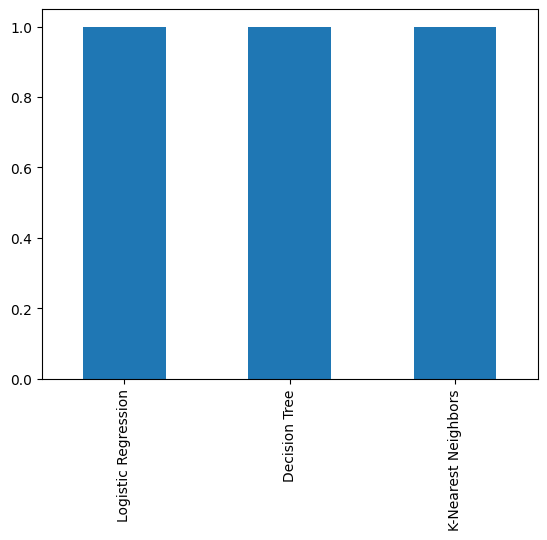

In [6]:
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=3)}
model_results = {}
for model_name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    model_results[model_name] = accuracy
    print(f"{model_name} Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred))

pd.DataFrame(model_results, index=['Accuracy']).T.plot(kind='bar', legend=False)

In [7]:
k=[1,5,20]
for i in k:
    model = KNeighborsClassifier(n_neighbors=i)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"KNN with k={i} Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred))


KNN with k=1 Accuracy: 0.9993
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.83      0.72      0.77        95

    accuracy                           1.00     56746
   macro avg       0.91      0.86      0.88     56746
weighted avg       1.00      1.00      1.00     56746

KNN with k=5 Accuracy: 0.9994
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.96      0.68      0.80        95

    accuracy                           1.00     56746
   macro avg       0.98      0.84      0.90     56746
weighted avg       1.00      1.00      1.00     56746

KNN with k=20 Accuracy: 0.9994
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.92      0.68      0.78        95

    accuracy                           1.00     56746
   macro avg       0.96      0.84    

In [8]:
depth=[2,5,10,None]
precision_scores_dt = []
recall_scores_dt = []
f1_scores_dt = []
for d in depth:
    model = DecisionTreeClassifier(max_depth=d)
    model.fit(x_train, y_train)
    y_pred_train = model.predict(x_train)
    y_pred_test = model.predict(x_test)
    accuracy_train = accuracy_score(y_train, y_pred_train)
    accuracy_test = accuracy_score(y_test, y_pred_test)
    precision = precision_score(y_test, y_pred_test)
    recall = recall_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test)
    precision_scores_dt.append(precision)
    recall_scores_dt.append(recall)
    f1_scores_dt.append(f1)
    print(f"Training Accuracy: {accuracy_train:.4f}")
    print(f"Testing Accuracy: {accuracy_test:.4f}")
    print(classification_report(y_test, y_pred_test))

Training Accuracy: 0.9993
Testing Accuracy: 0.9993
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.84      0.69      0.76        95

    accuracy                           1.00     56746
   macro avg       0.92      0.85      0.88     56746
weighted avg       1.00      1.00      1.00     56746

Training Accuracy: 0.9996
Testing Accuracy: 0.9993
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.89      0.69      0.78        95

    accuracy                           1.00     56746
   macro avg       0.95      0.85      0.89     56746
weighted avg       1.00      1.00      1.00     56746

Training Accuracy: 0.9998
Testing Accuracy: 0.9993
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.88      0.71      0.78        95

    accuracy                 

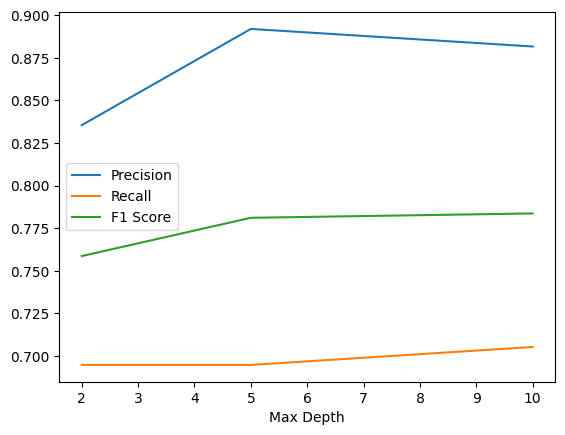

In [9]:
report_dt=pd.DataFrame({'Max Depth':depth,'Precision':precision_scores_dt,'Recall':recall_scores_dt,'F1 Score':f1_scores_dt})
report_dt.plot(x='Max Depth', y=['Precision', 'Recall', 'F1 Score'])
plt.show()

In [10]:
threshold=[0.3,0.5,0.7]
precision_scores = []
recall_scores = []
f1_scores = []
for i in threshold:
    model = LogisticRegression()
    model.fit(X_train_scaled, y_train)
    y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]
    y_pred = (y_pred_prob >= i).astype(int)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)
    print(f"Logistic Regression with threshold={i} Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred))


Logistic Regression with threshold=0.3 Accuracy: 0.9992
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.84      0.64      0.73        95

    accuracy                           1.00     56746
   macro avg       0.92      0.82      0.86     56746
weighted avg       1.00      1.00      1.00     56746

Logistic Regression with threshold=0.5 Accuracy: 0.9991
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.85      0.58      0.69        95

    accuracy                           1.00     56746
   macro avg       0.92      0.79      0.84     56746
weighted avg       1.00      1.00      1.00     56746

Logistic Regression with threshold=0.7 Accuracy: 0.9990
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.84      0.52      0.64        95

    accuracy  

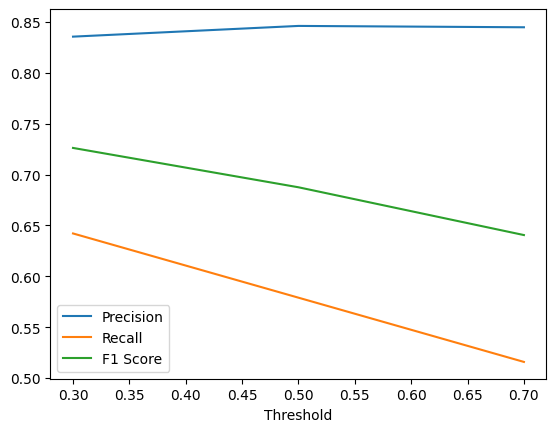

In [11]:
report_logestic=pd.DataFrame({'Threshold':threshold,'Precision':precision_scores,'Recall':recall_scores,'F1 Score':f1_scores})
report_logestic.plot(x='Threshold', y=['Precision', 'Recall', 'F1 Score'])
plt.show()

In [12]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid={'max_depth': [2, 3, 4, 5, 6, 8, 10, 15, 20, None]},
    cv=cv,
    scoring='recall',
    n_jobs=1
)

grid.fit(x_train, y_train)

print("Best depth:", grid.best_params_['max_depth'])
print("Best CV Recall:", grid.best_score_)

Best depth: 4
Best CV Recall: 0.7989824561403508


In [13]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos

model = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1,
    eval_metric="aucpr",
    random_state=42
)

model.fit(x_train, y_train)

y_prob = model.predict_proba(x_test)[:, 1]
for threshold in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:

    y_pred = (y_prob >= threshold).astype(int)

    print(f"\nThreshold: {threshold}")
    print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

print("PR-AUC:", average_precision_score(y_test, y_prob))


Threshold: 0.1
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56651
           1       0.21      0.85      0.34        95

    accuracy                           0.99     56746
   macro avg       0.61      0.92      0.67     56746
weighted avg       1.00      0.99      1.00     56746


Threshold: 0.2
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.39      0.84      0.53        95

    accuracy                           1.00     56746
   macro avg       0.69      0.92      0.77     56746
weighted avg       1.00      1.00      1.00     56746


Threshold: 0.3
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.51      0.83      0.63        95

    accuracy                           1.00     56746
   macro avg       0.76      0.92      0.82     56746
weighted avg       1.00   

In [14]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)


model.fit(x_train, y_train)


y_prob = model.predict_proba(x_test)[:, 1]


y_pred = (y_prob >= 0.5).astype(int)


print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("PR-AUC:", average_precision_score(y_test, y_prob))

Confusion Matrix:
[[56649     2]
 [   27    68]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.72      0.82        95

    accuracy                           1.00     56746
   macro avg       0.99      0.86      0.91     56746
weighted avg       1.00      1.00      1.00     56746

PR-AUC: 0.8093968801876994


In [15]:
for threshold in [0.5, 0.4, 0.3, 0.2, 0.1]:

    y_pred = (y_prob >= threshold).astype(int)

    print(f"\nThreshold = {threshold}")
    print(classification_report(y_test, y_pred))


Threshold = 0.5
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.72      0.82        95

    accuracy                           1.00     56746
   macro avg       0.99      0.86      0.91     56746
weighted avg       1.00      1.00      1.00     56746


Threshold = 0.4
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.73      0.83        95

    accuracy                           1.00     56746
   macro avg       0.99      0.86      0.92     56746
weighted avg       1.00      1.00      1.00     56746


Threshold = 0.3
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.96      0.74      0.83        95

    accuracy                           1.00     56746
   macro avg       0.98      0.87      0.92     56746
weighted avg       1.00

In [18]:
model = RandomForestClassifier(
    n_estimators=500,
    max_depth=13,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight={0: 1, 1: 100},
    random_state=42,
    n_jobs=-1
)

model.fit(x_train, y_train)

y_prob = model.predict_proba(x_test)[:, 1]

y_pred = (y_prob >= 0.5).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("PR-AUC:", average_precision_score(y_test, y_prob))

Confusion Matrix:
[[56646     5]
 [   27    68]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.93      0.72      0.81        95

    accuracy                           1.00     56746
   macro avg       0.97      0.86      0.90     56746
weighted avg       1.00      1.00      1.00     56746

PR-AUC: 0.8130974075488971


In [ ]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

model = XGBClassifier(
    objective="binary:logistic",
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",
    random_state=42
)

param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [3, 5],
    "learning_rate": [0.03, 0.05],
    "min_child_weight": [1, 3]
}

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=1,
    verbose=1
)

grid.fit(x_train, y_train)

print("Best parameters:")
print(grid.best_params_)

print("Best CV F1:")
print(grid.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters:
{'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 400}
Best CV Recall:
0.8572023462073115


In [29]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(x_train, y_train)

print("Best Parameters:")
print(grid_rf.best_params_)

print("\nBest CV F1:")
print(grid_rf.best_score_)

Fitting 5 folds for each of 96 candidates, totalling 480 fits
Best Parameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 400}

Best CV F1:
0.8488339204357075


In [ ]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos



xgb_model = XGBClassifier(
  n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    min_child_weight=1,

    scale_pos_weight=scale_pos_weight,

    eval_metric="aucpr",
    random_state=42
)



rf_model = RandomForestClassifier(max_depth=None, max_features= 'sqrt', min_samples_leaf= 2, min_samples_split= 5, n_estimators= 400
)



lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ))
])



print("Training XGBoost...")
xgb_model.fit(x_train, y_train)

print("Training Random Forest...")
rf_model.fit(x_train, y_train)

print("Training Logistic Regression...")
lr_model.fit(x_train, y_train)



xgb_prob = xgb_model.predict_proba(x_test)[:, 1]

rf_prob = rf_model.predict_proba(x_test)[:, 1]

lr_prob = lr_model.predict_proba(x_test)[:, 1]



w_xgb = 0.4
w_rf = 0.4
w_lr = 0.2

ensemble_prob = (
    w_xgb * xgb_prob +
    w_rf * rf_prob +
    w_lr * lr_prob
)



best_threshold = None
best_precision = None
best_recall = None
best_score = float("inf")

for threshold in np.arange(0.01, 1.00, 0.01):

    y_pred = (ensemble_prob >= threshold).astype(int)

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    score = (
        abs(precision - 0.90) +
        abs(recall - 0.90)
    )

    if score < best_score:
        best_score = score
        best_threshold = threshold
        best_precision = precision
        best_recall = recall


y_pred = (
    ensemble_prob >= best_threshold
).astype(int)


print("\n==============================")
print("ENSEMBLE RESULTS")
print("==============================")

print("Best Threshold:", best_threshold)

print("Precision:", best_precision)

print("Recall:", best_recall)

print("F1:", f1_score(y_test, y_pred))

print(
    "PR-AUC:",
    average_precision_score(y_test, ensemble_prob)
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Training XGBoost...
Training Random Forest...
Training Logistic Regression...

ENSEMBLE RESULTS
Best Threshold: 0.43
Precision: 0.9047619047619048
Recall: 0.8
F1: 0.8491620111731844
PR-AUC: 0.8351205834899043

Confusion Matrix:
[[56643     8]
 [   19    76]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.90      0.80      0.85        95

    accuracy                           1.00     56746
   macro avg       0.95      0.90      0.92     56746
weighted avg       1.00      1.00      1.00     56746

